### FUCTIONALITY

- Generated the Labelled set of data sequences for every windows. `summary_df_train_30D-{sw}SW-{tag_l}.csv`
- Generated time randomised labelled set of data `RDM_df_train_30D-{sw}SW-{tag_l}.csv`

In [1]:

import sys
sys.path.append('C:\PROJECT-DEMETER\Demeter_retrain') 

from lstm import HalfOrbitPairDataset
from lstm.scaling import scale_datasets
from lstm import LSTMAutoencoder
from lstm import train_lstm_ae
from lstm import plot_encoded_representation
from lstm.anomaly_detection import AnomalyDetector
from lstm import SeismicAnomalyAnalyzer
from lstm import SeismicCriteria
from lstm import train_lstm_ae_mode
from lstm import SeismicAnalysis
from lstm import SeismicRatioEvaluator

from datetime import datetime

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import os
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import random
import seaborn as sns
from shapely.geometry import Point, Polygon
from datetime import timedelta
import torch.optim as optim
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import glob
# kasdfkhaflkj
plt.style.use('default')

torch.manual_seed(201894)
np.random.seed(201894)


<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_17868\2597198312.py:2: SyntaxWarning: invalid escape sequence '\P'
  sys.path.append('C:\PROJECT-DEMETER\Demeter_retrain')


In [ ]:
output_dir = f'C:\\PROJECT-DEMETER\\Demeter_Retrain\\output_base\\Bg_window_data\\RST'
os.makedirs(output_dir, exist_ok=True)
# output_model = r"C:\PROJECT-DEMETER\Demeter_Retrain\model_base"
# os.makedirs(output_dir, exist_ok=True)


In [ ]:


# parameters
train_months = 12
val_months   = 3
min_data_points = 17
stride = 3

tw = 48
sw = 10


In [ ]:

# storm conditions 
storm_data = pd.read_pickle('C:\PROJECT-DEMETER\CORRECTED-FILES\Data_Preperation\storm_data.pkl')
data = pd.read_pickle(r"C:\PROJECT-DEMETER\CORRECTED-FILES\Data_Preperation\Down_Orbits-Q3-loc-Train-limitedgrids_RES.pkl")

# Drop all columns that start with 'Q3' (keep Res_Q3_* features + lat/lon/time index)
df = data.loc[:, ~data.columns.str.startswith('Q3')]
# df = df_all[df_all.index <= '2005-09-30']
# Earthquake catalog; make sure Time is UTC-aware for valid comparisons
eq = pd.read_csv("C:\PROJECT-DEMETER\Recovery-HD\EarthQuake-Data\EQ.csv", parse_dates=['Time'])
eq['Time'] = pd.to_datetime(eq['Time'], errors="coerce")
eq['Time'] = pd.to_datetime(eq['Time']).dt.strftime('%Y-%m-%d %H:%M:%S')
eq['Time'] = pd.to_datetime(eq['Time'])



Dst = -50 # if dst < -50 nT it has to be removed
Kp = 3 # if kp > 3 nT it has to be removed
AE = 500 # if AE >500nT it has to be removed 

storm_all = storm_data[
    (storm_data['Dst'] < Dst) |
    (storm_data['Kp']  > Kp) |
    (storm_data['AE']  > AE)
].copy()


storm_all['Datetime'] = pd.to_datetime(storm_all['Datetime'])


<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:9: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:9: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_24588\585639950.py:2: SyntaxWarning: invalid escape sequence '\P'
  storm_data = pd.read_pickle('C:\PROJECT-DEMETER\CORRECTED-FILES\Data_Preperation\storm_data.pkl')
C:\Users\mbabu\AppData\Local\Temp\ipykernel_24588\585639950.py:9: SyntaxWarning: invalid escape sequence '\P'
  eq = pd.read_csv("C:\PROJECT-DEMETER\Recovery-HD\EarthQuake-Data\EQ.csv", parse_dates=['Time'])


In [ ]:
data

,Q3_fb_1,lat,lon,Res_Q3_fb_1,Q3_fb_2,Res_Q3_fb_2,Q3_fb_3,Res_Q3_fb_3,Q3_fb_4,Res_Q3_fb_4,...,Q3_fb_7,Res_Q3_fb_7,Q3_fb_8,Res_Q3_fb_8,Q3_fb_9,Res_Q3_fb_9,Q3_fb_10,Res_Q3_fb_10,Q3_fb_11,Res_Q3_fb_11
datetime,,,,,,,,,,,,,,,,,,,,,
2005-01-01 00:05:36.579,2.044331,67.5644,172.7907,1.828858,1.022945,1.422316,1.471744,1.485098,1.734324,0.365655,...,1.518998,0.180102,1.232212,0.128261,1.132497,0.240991,0.986470,0.618205,0.913925,1.046810
2005-01-01 00:07:39.459,0.936488,60.5094,166.5650,0.721016,0.350716,0.750089,0.797767,0.811125,1.653489,0.284825,...,1.396183,0.057292,1.121392,0.017445,1.039005,0.147505,0.800572,0.432312,0.314551,0.447442
2005-01-01 00:09:42.540,-0.004689,53.2904,162.4045,-0.220159,-0.201933,0.197442,0.297729,0.311090,2.006430,0.637771,...,0.494877,-0.844008,0.228925,-0.875017,0.178038,-0.713458,-0.073968,-0.442223,-0.356579,-0.223682
2005-01-01 00:11:45.420,-0.318414,46.0087,159.3144,0.630721,-0.473562,0.640605,0.964396,0.596627,2.050502,0.927470,...,-0.344529,0.329737,-0.675444,0.378596,-0.820042,0.638381,-1.052359,0.692393,-1.208733,0.798213
2005-01-01 00:13:48.077,-0.632140,38.7005,156.8341,0.316999,-0.669641,0.444535,1.552017,1.184258,1.900750,0.777726,...,-0.961850,-0.287579,-1.267790,-0.213745,-1.548786,-0.090359,-1.819926,-0.075169,-2.001766,0.005183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-12-16 17:25:11.610,-0.815815,-36.9934,-123.8308,-0.009683,-0.944151,0.470400,1.397587,1.116015,0.991679,0.561714,...,-2.088845,-0.036247,-2.319499,-0.003479,-2.477325,0.101927,-2.478077,0.291335,-2.576271,0.265015
2010-12-16 17:27:14.490,-0.737384,-44.3788,-126.1590,0.068747,-1.221541,0.193008,-0.677741,-0.959314,1.501482,1.071517,...,-1.065925,0.986678,-1.402416,0.913608,-1.787136,0.792120,-2.072353,0.697062,-2.277357,0.563932
2010-12-16 17:29:17.370,-1.011893,-51.7250,-129.0128,-0.176642,-0.907815,0.791706,-0.952250,0.343836,1.300547,1.000967,...,-0.203833,0.399193,-0.236847,0.679890,-0.335339,1.168828,-0.562918,1.424849,-1.260851,1.240434


In [ ]:


def correct_anomalies_for_storms(datetime_sequences, anomalies_agg, anomalies_fb, storm_all):
    """
    Removes storm-affected sequences from anomalies.

    Parameters:
    - datetime_sequences: list of list-like sequences of timestamps
    - anomalies_agg: list of indices (int) of aggregated anomalies
    - anomalies_fb: list of lists of per-sequence anomaly indices
    - storm_all: DataFrame with 'Datetime' column containing storm event timestamps

    Returns:
    - corrected_anomalies_agg: filtered list of anomalies_agg
    - corrected_anomalies_fb: filtered list of lists of anomalies_fb
    - storm_data_indices: indices of sequences affected by storms
    """
    storm_data_indices = []
    storm_all['Datetime'] = pd.to_datetime(storm_all['Datetime'])

    for idx, seq in enumerate(datetime_sequences):
        seq_times = pd.to_datetime(seq)
        start_t, end_t = seq_times[0], seq_times[-1]
        if storm_all['Datetime'].between(start_t, end_t).any():
            storm_data_indices.append(idx)

    corrected_anomalies_agg = [
        idx for idx in anomalies_agg if idx not in storm_data_indices
    ]

    corrected_anomalies_fb = [[] for _ in range(len(anomalies_fb))]
    for i, anomalies in enumerate(anomalies_fb):
        for j in anomalies:
            if j not in storm_data_indices:
                corrected_anomalies_fb[i].append(j)

    return corrected_anomalies_agg, corrected_anomalies_fb, storm_data_indices


In [ ]:



def run_seismic_analysis(
    dataset,
    test_dataset,
    eq,
    seismic_criteria,
    corrected_test_fb_anomalies,
    corrected_test_anomalies,
    model_name,
    output_dir,
    data_label=""
):
  

    # Create instance
    sa = SeismicAnalysis(
        dataset=dataset,
        earthquake_catalog=eq,
        create_half_orbit_sequences=test_dataset.create_half_orbit_sequences,
        is_eq_fn=seismic_criteria.is_eq,
        model_name=f'{model_name}',
        threshold_label="98",
        mean_rst=0,
        sigma_rst=0,
        output_dir=output_dir
    )

    seismic_seqs_agg, matched_eqs_agg, missed_eqs_agg = sa.agg_analysis(
        data_label=data_label,
        anomalous_indices=corrected_test_anomalies,
        plot=False
    )

    total_sequences_agg = len(corrected_test_anomalies)
    anomalies_agg = len(seismic_seqs_agg)

    if total_sequences_agg > 0:
        p_agg = anomalies_agg / total_sequences_agg
        agg_value = p_agg * 100
        agg_error = np.sqrt(p_agg * (1 - p_agg) / total_sequences_agg) * 100
    else:
        agg_value, agg_error = 0, 0

    results = {
        "agg": {"value": agg_value, "error": agg_error}
    }

    return results



In [ ]:


# function to generate rolling windows
def generate_windows(start_date, end_date, train_months, val_months):
    """
    Generate train/val windows from start to end date.
    Each window: 12m train + 3m val.
    """
    windows = []
    current = pd.to_datetime(start_date)

    while current + pd.DateOffset(months=train_months + val_months) < pd.to_datetime(end_date):
        train_start = current
        train_end   = current + pd.DateOffset(months=train_months)
        val_end     = train_end + pd.DateOffset(months=val_months)

        windows.append({
            "train_start": train_start,
            "train_end": train_end,
            "val_start": train_end,
            "val_end": val_end
        })

        # slide window forward (e.g. by 3 months, or 1 month depending on design)
        current = current + pd.DateOffset(months=3)

    return windows



In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import rcParams

# Font
rcParams['font.family'] = 'Times New Roman'

def plot_q3_vs_residual(df,  fb="FB5", save_path=None):

    col_raw = "Q3_fb_1"
    col_res = "Res_Q3_fb_1"

    # --- Validation ---
    if col_raw not in df.columns or col_res not in df.columns:
        raise ValueError("Required columns not found")

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Index must be DatetimeIndex")

    # --- Shared y-limits ---
    y_min = min(df[col_raw].min(), df[col_res].min())
    y_max = max(df[col_raw].max(), df[col_res].max())

    # Add small margin
    margin = 0.1 * (y_max - y_min)
    y_min -= margin
    y_max += margin

    # --- Create subplot ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)

    # =========================
    # (a) RAW
    # =========================
    axes[0].scatter(df.index, df[col_raw],
                    s=15, alpha=0.7)

    axes[0].set_title(f"(a) Raw Time Series ( {fb})", fontsize=18)
    axes[0].set_ylabel("Q3", fontsize=16)
    axes[0].grid(True, linestyle="--", alpha=0.4)
    axes[0].set_ylim(y_min, y_max)
    axes[0].tick_params(axis='both', labelsize=14)

    # =========================
    # (b) RESIDUAL
    # =========================
    axes[1].scatter(df.index, df[col_res],
                    s=15, alpha=0.7)

    axes[1].axhline(0, color='black', lw=1)

    axes[1].set_title(f"(b) Background-Corrected Residuals ({fb})", fontsize=18)
    axes[1].set_xlabel("Time", fontsize=16)
    axes[1].set_ylabel("Residual Q3", fontsize=16)
    axes[1].grid(True, linestyle="--", alpha=0.4)
    axes[1].set_ylim(y_min, y_max)
    axes[1].tick_params(axis='both', labelsize=14)

    # =========================
    # X-axis formatting
    # =========================
    axes[1].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

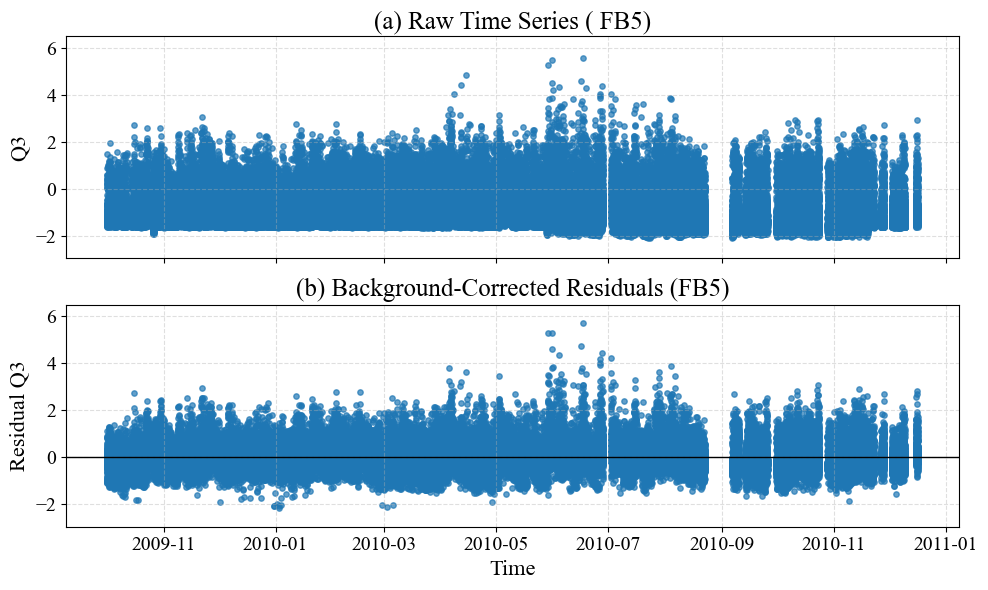

In [ ]:
plot_q3_vs_residual(df1, fb="FB5")

In [ ]:
df

,lat,lon,Res_Q3_fb_1,Res_Q3_fb_2,Res_Q3_fb_3,Res_Q3_fb_4,Res_Q3_fb_5,Res_Q3_fb_6,Res_Q3_fb_7,Res_Q3_fb_8,Res_Q3_fb_9,Res_Q3_fb_10,Res_Q3_fb_11
datetime,,,,,,,,,,,,,
2005-01-01 00:05:36.579,67.5644,172.7907,1.828858,1.422316,1.485098,0.365655,0.572577,0.333397,0.180102,0.128261,0.240991,0.618205,1.046810
2005-01-01 00:07:39.459,60.5094,166.5650,0.721016,0.750089,0.811125,0.284825,0.402194,0.242684,0.057292,0.017445,0.147505,0.432312,0.447442
2005-01-01 00:09:42.540,53.2904,162.4045,-0.220159,0.197442,0.311090,0.637771,-0.106989,-0.610349,-0.844008,-0.875017,-0.713458,-0.442223,-0.223682
2005-01-01 00:11:45.420,46.0087,159.3144,0.630721,0.640605,0.596627,0.927470,0.707778,0.508733,0.329737,0.378596,0.638381,0.692393,0.798213
2005-01-01 00:13:48.077,38.7005,156.8341,0.316999,0.444535,1.184258,0.777726,0.191292,-0.118712,-0.287579,-0.213745,-0.090359,-0.075169,0.005183
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-12-16 17:25:11.610,-36.9934,-123.8308,-0.009683,0.470400,1.116015,0.561714,-0.193614,-0.180807,-0.036247,-0.003479,0.101927,0.291335,0.265015
2010-12-16 17:27:14.490,-44.3788,-126.1590,0.068747,0.193008,-0.959314,1.071517,0.671682,0.813280,0.986678,0.913608,0.792120,0.697062,0.563932
2010-12-16 17:29:17.370,-51.7250,-129.0128,-0.176642,0.791706,0.343836,1.000967,0.432361,0.328175,0.399193,0.679890,1.168828,1.424849,1.240434


In [ ]:

# Example: generate windows
windows_train = generate_windows(start_date="2005-01-01 00:00:00", end_date="2011-01-02 00:00:00",
                           train_months=12, val_months=3)

all_results = []
# iterate through windows
for i, w in enumerate(windows_train):

    tag_l = f'tw{tw}_w{i}'


    print(f"Window {i}: Train {w['train_start']} → {w['train_end']}, "
          f"Val {w['val_start']} → {w['val_end']}")
    df1 =  pd.read_pickle(f"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\Background_data-window_{i}.pkl")
    # subset data
    train_set = df1[(df1.index >= w['train_start']) & (df1.index < w['train_end'])]
    val_set  = df1[(df1.index >= w['val_start'])   & (df1.index < w['val_end'])]
    if w == 19:
        plt.plot(df1) 

<>:14: SyntaxWarning: invalid escape sequence '\P'
<>:14: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_24588\2785827161.py:14: SyntaxWarning: invalid escape sequence '\P'
  df1 =  pd.read_pickle(f"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\Background_data-window_{i}.pkl")


Window 0: Train 2005-01-01 00:00:00 → 2006-01-01 00:00:00, Val 2006-01-01 00:00:00 → 2006-04-01 00:00:00
Window 1: Train 2005-04-01 00:00:00 → 2006-04-01 00:00:00, Val 2006-04-01 00:00:00 → 2006-07-01 00:00:00
Window 2: Train 2005-07-01 00:00:00 → 2006-07-01 00:00:00, Val 2006-07-01 00:00:00 → 2006-10-01 00:00:00
Window 3: Train 2005-10-01 00:00:00 → 2006-10-01 00:00:00, Val 2006-10-01 00:00:00 → 2007-01-01 00:00:00
Window 4: Train 2006-01-01 00:00:00 → 2007-01-01 00:00:00, Val 2007-01-01 00:00:00 → 2007-04-01 00:00:00
Window 5: Train 2006-04-01 00:00:00 → 2007-04-01 00:00:00, Val 2007-04-01 00:00:00 → 2007-07-01 00:00:00
Window 6: Train 2006-07-01 00:00:00 → 2007-07-01 00:00:00, Val 2007-07-01 00:00:00 → 2007-10-01 00:00:00
Window 7: Train 2006-10-01 00:00:00 → 2007-10-01 00:00:00, Val 2007-10-01 00:00:00 → 2008-01-01 00:00:00
Window 8: Train 2007-01-01 00:00:00 → 2008-01-01 00:00:00, Val 2008-01-01 00:00:00 → 2008-04-01 00:00:00
Window 9: Train 2007-04-01 00:00:00 → 2008-04-01 00:00:

##   Summary Data Generation

 -  labelled
 set of window data

In [ ]:

# Example: generate windows
windows_train = generate_windows(start_date="2005-01-01 00:00:00", end_date="2011-01-02 00:00:00",
                           train_months=12, val_months=3)

all_results = []
# iterate through windows
for i, w in enumerate(windows_train):

    tag_l = f'tw{tw}_w{i}'


    print(f"Window {i}: Train {w['train_start']} → {w['train_end']}, "
          f"Val {w['val_start']} → {w['val_end']}")
    df1 =  pd.read_pickle(f"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\Background_data-window_{i}.pkl")
    # subset data
    train_set = df1[(df1.index >= w['train_start']) & (df1.index < w['train_end'])]
    val_set  = df1[(df1.index >= w['val_start'])   & (df1.index < w['val_end'])]


    # datasets (non-seismic only for fitting scaler + training)
    train_dataset = HalfOrbitPairDataset(train_set, min_data_points=min_data_points)
    val_dataset   = HalfOrbitPairDataset(val_set,   min_data_points=min_data_points)


    seismic_criteria = SeismicCriteria(spatial_width=sw, time_window_hours=tw)
    
    df_train_labels = seismic_criteria.label_sequences(dataset=train_dataset, earthquakes=eq,
                                                       save_path=os.path.join(output_dir, f"summary_df_train_30D-{sw}SW-{tag_l}.csv"))
    df_val_labels   = seismic_criteria.label_sequences(dataset=val_dataset,   earthquakes=eq,
                                                       save_path=os.path.join(output_dir, f"summary_df_val_30D-{sw}SW-{tag_l}.csv"))



    


<>:14: SyntaxWarning: invalid escape sequence '\P'
<>:14: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_25584\2201370908.py:14: SyntaxWarning: invalid escape sequence '\P'
  df1 =  pd.read_pickle(f"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\Background_data-window_{i}.pkl")


Window 0: Train 2005-01-01 00:00:00 → 2006-01-01 00:00:00, Val 2006-01-01 00:00:00 → 2006-04-01 00:00:00


[INFO] Total valid combined sequences: 1553
[INFO] Saved summary DataFrame to C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\BEST\summary_df_train_30D-22SW-tw48_w0.csv
[INFO] Total seismic sequences found: 0
[INFO] Unique earthquakes matched: 1246
[INFO] Total valid combined sequences: 381
[INFO] Saved summary DataFrame to C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\BEST\summary_df_val_30D-22SW-tw48_w0.csv
[INFO] Total seismic sequences found: 0
[INFO] Unique earthquakes matched: 216
Window 1: Train 2005-04-01 00:00:00 → 2006-04-01 00:00:00, Val 2006-04-01 00:00:00 → 2006-07-01 00:00:00
[INFO] Total valid combined sequences: 1515
[INFO] Saved summary DataFrame to C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\BEST\summary_df_train_30D-22SW-tw48_w1.csv
[INFO] Total seismic sequences found: 0
[INFO] Unique earthquakes matched: 949
[INFO] Total valid combined sequences: 434
[INFO] Saved summary DataFrame to C:\PROJECT-DEMETER\Demeter_Retrain

## For Time RANDOMISATION - HELP TO MAKE RST

In [ ]:
import pandas as pd
import random

def label_sequences_RDM(dataset, earthquakes, spatial_width, time_window_hours, save_path=None):
    """
    Label each half-orbit sequence based on whether any location within the sequence
    is seismic within a configured spatial/time window, using a random offset (5–30 days)
    from the last timestamp.

    Args:
        dataset: HalfOrbitPairDataset instance (e.g., train/val/test dataset).
        earthquakes (pd.DataFrame): Earthquake catalog with ['Time','lat','long','mag'].
        spatial_width (float): Spatial proximity threshold (e.g., 20 degrees).
        time_window_hours (float): Time window threshold (in hours).
        save_path (str, optional): If provided, CSV path to save the summary.

    Returns:
        pd.DataFrame with columns:
        ['index', 'time_window', 'label', 'matched_eqs', 'total_eq', 'random_offset_days']
    """

    # Create a criteria instance for seismic proximity checking
    criteria = SeismicCriteria(spatial_width, time_window_hours)

    # Build sequences (from dataset.df)
    _, dt_seqs, latlon_seqs, _ = dataset.create_half_orbit_sequences(dataset.df)

    sequence_summary = []
    matched_eqs_records = []  

    for idx, (dt_seq, latlon_seq) in enumerate(zip(dt_seqs, latlon_seqs)):
        # Random offset between 5 and 30 days
        random_days = random.randint(5, 30)
        anomaly_time = dt_seq[-1] + pd.Timedelta(days=random_days)

        label = 0
        seq_matched_eqs = []

        # Check seismic condition for all locations in sequence
        for loc in latlon_seq:
            is_seismic, inside_eqs, _ = criteria.is_eq(anomaly_time, loc, earthquakes)
            if inside_eqs:
                seq_matched_eqs.extend(inside_eqs)
            if is_seismic:
                label = 1

        sequence_summary.append({
            "index": idx,
            "time_window": anomaly_time,
            "label": label,
            "matched_eqs": seq_matched_eqs,
            "total_eq": len(seq_matched_eqs),
            "random_offset_days": random_days
        })

        matched_eqs_records.extend(seq_matched_eqs)

    summary_df = pd.DataFrame(sequence_summary).reset_index(drop=True)

    # Unique EQs matched
    if matched_eqs_records:
        matched_eqs_df = pd.DataFrame(matched_eqs_records).drop_duplicates()
    else:
        matched_eqs_df = pd.DataFrame(columns=["lat", "long", "Time", "mag"])

    # Optional: save results
    if save_path:
        summary_df.to_csv(save_path, index=False)
        print(f"[INFO] Saved summary DataFrame to {save_path}")

    print(f"[INFO] Total labeled sequences: {len(summary_df)}")
    print(f"[INFO] Unique earthquakes matched: {len(matched_eqs_df)}")

    return summary_df


# Preparing RDM files 

[Randomised timing of sequences for earthquale search]

In [ ]:

# Example: generate windows
windows_train = generate_windows(start_date="2005-01-01 00:00:00", end_date="2011-01-02 00:00:00",
                           train_months=12, val_months=3)

all_results = []
# iterate through windows
for i, w in enumerate(windows_train):
      # if i== 0:

      tag_l = f'tw{tw}_w{i}'


      print(f"Window {i}: Train {w['train_start']} → {w['train_end']}, "
            f"Val {w['val_start']} → {w['val_end']}")
      df1 =  pd.read_pickle(f"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\Background_data-window_{i}.pkl")
      # subset data
      train_set = df1[(df1.index >= w['train_start']) & (df1.index < w['train_end'])]
      val_set  = df1[(df1.index >= w['val_start'])   & (df1.index < w['val_end'])]
      test_set  = pd.DataFrame(df[df.index >= '2010-01-01'])

      # datasets (non-seismic only for fitting scaler + training)
      train_dataset = HalfOrbitPairDataset(train_set, min_data_points=min_data_points)
      val_dataset   = HalfOrbitPairDataset(val_set,   min_data_points=min_data_points)

      seismic_criteria = SeismicCriteria(spatial_width=sw, time_window_hours=tw)
            
      # label_sequences(dataset, earthquakes, spatial_width, time_window_hours, save_path=None)
      df_train_labels = label_sequences_RDM(dataset=train_dataset, earthquakes=eq,spatial_width=22, time_window_hours=tw,
                                                            save_path=os.path.join(output_dir, f"RDM_df_train_30D-{sw}SW-{tag_l}.csv"))
      df_val_labels   =label_sequences_RDM(dataset=val_dataset,   earthquakes=eq,spatial_width=sw, time_window_hours=tw,
                                                            save_path=os.path.join(output_dir, f"RDM_df_val_30D-{sw}SW-{tag_l}.csv"))

    

    


Window 0: Train 2005-01-01 00:00:00 → 2006-01-01 00:00:00, Val 2006-01-01 00:00:00 → 2006-04-01 00:00:00


<>:15: SyntaxWarning: invalid escape sequence '\P'
<>:15: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_25584\2552706215.py:15: SyntaxWarning: invalid escape sequence '\P'
  df1 =  pd.read_pickle(f"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\Background_data-window_{i}.pkl")


[INFO] Total valid combined sequences: 1553
[INFO] Total valid combined sequences: 1553
[INFO] Saved summary DataFrame to C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\BEST\RDM_df_train_30D-22SW-tw48_w0.csv
[INFO] Total labeled sequences: 1553
[INFO] Unique earthquakes matched: 987
[INFO] Total valid combined sequences: 381
[INFO] Saved summary DataFrame to C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\BEST\RDM_df_val_30D-22SW-tw48_w0.csv
[INFO] Total labeled sequences: 381
[INFO] Unique earthquakes matched: 271
Window 1: Train 2005-04-01 00:00:00 → 2006-04-01 00:00:00, Val 2006-04-01 00:00:00 → 2006-07-01 00:00:00
[INFO] Total valid combined sequences: 1515
[INFO] Total valid combined sequences: 1515
[INFO] Saved summary DataFrame to C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\BEST\RDM_df_train_30D-22SW-tw48_w1.csv
[INFO] Total labeled sequences: 1515
[INFO] Unique earthquakes matched: 903
[INFO] Total valid combined sequences: 434
[IN

# Random Sampling Test Using RDM files

[LOAD] C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\RDM_df_val_30D-22SW-tw12_w0.csv
[LOAD] C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\RDM_df_val_30D-22SW-tw12_w1.csv
[LOAD] C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\RDM_df_val_30D-22SW-tw12_w2.csv
[LOAD] C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\RDM_df_val_30D-22SW-tw12_w3.csv
[LOAD] C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\RDM_df_val_30D-22SW-tw12_w4.csv
[LOAD] C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\RDM_df_val_30D-22SW-tw12_w5.csv
[LOAD] C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\RDM_df_val_30D-22SW-tw12_w6.csv
[LOAD] C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\RDM_df_val_30D-22SW-tw12_w7.csv
[LOAD] C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\RDM_df_val_30D-22SW-tw12_w8.csv
[LOAD] C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\RDM_df_val_30D-22SW-tw

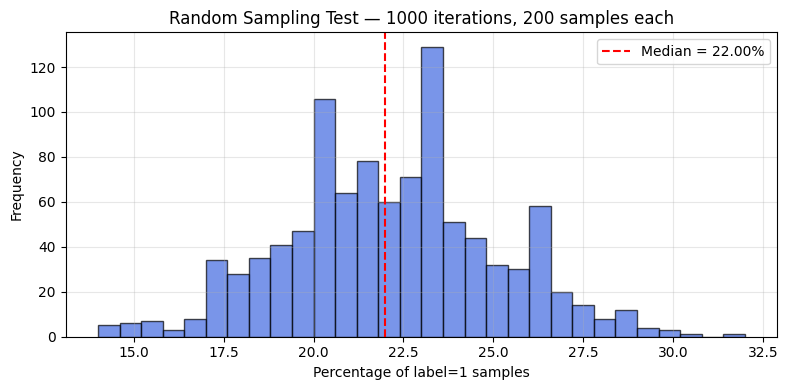

In [8]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# === LOAD DATA ===
dfs = []
tw = 12
sw=22
# === CONFIG ===
base_dir = r"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data"
pattern = fr"RDM_df_val_30D-{sw}SW-tw{tw}_w*.csv"
train_path = os.path.join(base_dir, fr"RDM_df_train_30D-{sw}SW-tw{tw}_w0.csv")

N_SAMPLES = 200
N_ITER = 1000

# Include training data (w0)
if os.path.exists(train_path):
    df_train = pd.read_csv(train_path, parse_dates=["time_window"])
    dfs.append(df_train)

# Collect validation files that *end with* _w<number>.csv
all_files = [
    f for f in os.listdir(base_dir)
    if re.fullmatch(fr"RDM_df_val_30D-{sw}SW-tw{tw}_w\d+\.csv", f)
]

# Sort by numeric window index
all_files = sorted(all_files, key=lambda x: int(re.search(r"_w(\d+)\.csv", x).group(1)))

# Load validation sets
for file in all_files:
    val_path = os.path.join(base_dir, file)
    print(f"[LOAD] {val_path}")
    df_val = pd.read_csv(val_path, parse_dates=["time_window"])
    dfs.append(df_val)

# === MERGE ALL ===
if not dfs:
    raise FileNotFoundError("No matching CSV files found for the given tw/sw pattern.")

df_all = pd.concat(dfs, ignore_index=True)
print(f"[INFO] Loaded total {len(df_all):,} rows from {len(dfs)} files.")

# === RANDOM SAMPLING TEST ===
percentages = []

for i in range(N_ITER):
    sample = df_all.sample(
        n=min(N_SAMPLES, len(df_all)),
        replace=False,
        random_state=None
    )
    pct_label1 = (sample["label"] == 1).mean() * 100
    percentages.append(pct_label1)

# === STATS ===
percentages = np.array(percentages)
median_pct = np.median(percentages)
std_pct = np.std(percentages)

print(f"[RESULT] Median percentage of label=1: {median_pct:.2f}% ± {std_pct:.2f}% (n={N_ITER})")

# === PLOT ===
plt.figure(figsize=(8, 4))
plt.hist(percentages, bins=30, color="royalblue", alpha=0.7, edgecolor="black")
plt.axvline(median_pct, color="red", linestyle="--", label=f"Median = {median_pct:.2f}%")
plt.title(f"Random Sampling Test — {N_ITER} iterations, {N_SAMPLES} samples each")
plt.xlabel("Percentage of label=1 samples")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
# === PERCENTILES ===
q03 = np.percentile(percentages, 0.3)
q50 = np.percentile(percentages, 50)
q997 = np.percentile(percentages, 99.7)

# === CREATE DATAFRAME ===
key = tw
combined_wide = pd.DataFrame({
    "key": [key],
    "0.3_All": [q03],
    "q2_All": [q50],
    "99.7_All": [q997]
} ,index=[key])

print(combined_wide)


    key  0.3_All  q2_All  99.7_All
12   12     14.5    22.0      30.0


ORBITAL-Spatial Coverage PLOTS

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# -----------------------------
# Figure / font configuration
# -----------------------------
mpl.rcParams.update({

    "font.family": "serif",
    "font.serif": ["Times New Roman"],})


# -----------------------------
# Input coordinates

coords = np.array([[ 66.89  ,  29.8291],
       [ 59.7276,  24.0353],
       [ 52.4297,  20.1277],
       [ 45.1446,  17.2228],
       [ 37.7404,  14.8421],
       [ 30.3271,  12.8075],
       [ 22.8867,  10.9859],
       [ 15.4386,   9.3017],
       [  7.9867,   7.6996],
       [  0.5343,   6.1374],
       [ -6.9159,   4.5779],
       [-14.3614,   2.9848],
       [-21.7992,   1.3172],
       [-29.2257,  -0.4773],
       [-36.6356,  -2.4729],
       [-44.021 ,  -4.7851],
       [-51.368 ,  -7.6106],
       [ 59.916 ,  -0.3466],
       [ 52.6204,  -4.2874],
       [ 45.2553,  -7.2395],
       [ 37.8515,  -9.6268],
       [ 30.4249, -11.6692],
       [ 22.9845, -13.4932],
       [ 15.5364, -15.179 ],
       [  8.0844, -16.782 ],
       [  0.6318, -18.3446],
       [ -6.8186, -19.904 ],
       [-14.2643, -21.4965],
       [-21.7024, -23.1629],
       [-29.1292, -24.9554],
       [-36.5396, -26.9479],
       [-43.9256, -29.2553],
       [-51.2734, -32.0728],
       [-58.5569, -35.7678]])


In [ ]:
train_lat_long_sequences= [coords]

C:\Users\mbabu\AppData\Local\Temp\ipykernel_18672\16202372.py:39: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))


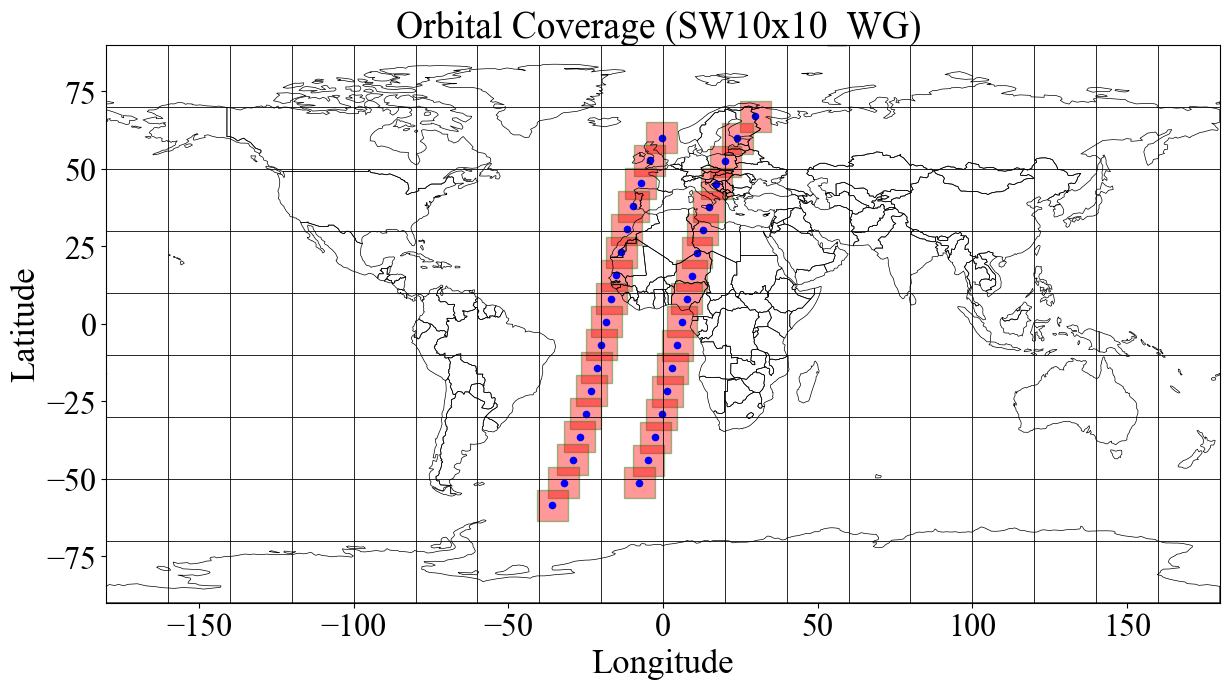

In [ ]:

import matplotlib.pyplot as plt
for i,loc in enumerate(train_lat_long_sequences):

    sw = 10
    coords = loc
    # coords = new_loc(coords)
    seismic_criteria = SeismicCriteria( sw,time_window_hours=48)

    squares = gpd.GeoDataFrame(
        geometry=[seismic_criteria.create_polygon(lat, lon) for i,( lat, lon) in enumerate(coords)],
        crs="EPSG:4326"
    )

    points = gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lat, lon in coords],
        crs="EPSG:4326"
    )

    # -----------------------------
    # Create 20° grid
    # -----------------------------
    grid_polys = []
    grid_labels = []
    for j, lat in enumerate(range(-90, 90, 20), start=1):
        for i, lon in enumerate(range(-180, 180, 20), start=1):
            grid_polys.append(Polygon([
                (lon, lat),
                (lon + 20, lat),
                (lon + 20, lat + 20),
                (lon, lat + 20)
            ]))
            grid_labels.append(f"G{(j-1)*18 + i}")

    grid = gpd.GeoDataFrame({"id": grid_labels, "geometry": grid_polys}, crs="EPSG:4326")

    # -----------------------------
    # Plot map
    # -----------------------------
    world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

    fig, ax = plt.subplots(figsize=(14, 7))
    world.boundary.plot(ax=ax, color="black", linewidth=0.5)
    grid.boundary.plot(ax=ax, color="black", linewidth=0.7, alpha=0.6)

    # # Label grid IDs
    # for geom, label in zip(grid.geometry, grid.id):
    #     x, y = geom.centroid.x, geom.centroid.y
    #     ax.text(x, y, label, fontsize=10, ha="center", va="center", color="k")

    # Plot polygons + points
    squares.plot(ax=ax, facecolor="red", alpha=0.4, edgecolor="green")
    points.plot(ax=ax, color="blue", markersize=20)

    # Style
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.set_xlabel("Longitude",fontsize=25)
    ax.set_ylabel("Latitude",fontsize=25)
    ax.set_title(f"Orbital Coverage (SW{sw}x{sw}_WG) ", fontsize=27)
        # ax2.set_ylabel("Mean sunspot number", fontsize=16)
    ax.tick_params(axis='both', labelsize=23)

    plt.grid(False)
    plt.tight_layout()
    plt.savefig(fr"C:\PROJECT-DEMETER\Paper1\Plots\\orbit_i_{sw}wg.png", dpi=600)
    plt.show()
